# 10 — Agent–Environment Interaction  
*How agents and environments talk to each other in RL.*

What you'll learn

- The agent–environment loop: how actions, states, and rewards evolve over time.  
- The structure of a trajectory $ (S_0, A_0, R_1, S_1, \dots) $.  
- Episodic vs continuing tasks and how we define returns.  
- Discounted return $ G_t $ and why discounting matters.  
- A tiny bandit environment to simulate interaction and visualize returns.

> This notebook sets the conceptual foundation for everything in RL: MDPs, Bellman equations, DP, Monte Carlo, TD, and beyond.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# For reproducibility
rng = np.random.default_rng(0)

def plot_series(values, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(6.4, 3.6))
    plt.plot(values, marker="o", alpha=0.8)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

## 1. The Agent–Environment Loop

In reinforcement learning, we model interaction as a repeated loop between:
- the agent (the learner/decision-maker), and  
- the environment (everything else).

At each discrete time step $ t = 0, 1, 2, \dots $:

1. The agent observes a state $ S_t $.
2. The agent selects an action $ A_t $ according to its policy $ \pi $:
   $$
   A_t \sim \pi(\cdot \mid S_t).
   $$
3. The environment responds with:
   - a reward $ R_{t+1} $,
   - the next state $ S_{t+1} $.

This yields a trajectory:
$$
S_0, A_0, R_1, S_1, A_1, R_2, S_2, \dots
$$

The agent’s goal is to choose actions to maximize some notion of cumulative reward over time.


### Episodic vs Continuing Tasks

- Episodic tasks: interaction breaks into episodes
  $$
  S_0, A_0, R_1, \dots, S_T
  $$
  where $ T $ is a (random) terminal time.

- Continuing tasks: interaction goes on indefinitely with no terminal state.

In both cases, we will soon define a return $ G_t $ that aggregates rewards into a scalar objective.


### RL Connection

This loop is the backbone of everything in RL:

- Dynamic Programming, Monte Carlo, and TD all estimate value functions based on the sequence $ (S_t, A_t, R_{t+1}) $.
- Policy Gradient and Actor–Critic methods adjust the policy $ \pi(a \mid s) $ using information from these trajectories.
- Environments like Gymnasium implement this loop via `reset()` and `step()` calls.

![Agent-Environment Loop](../assets/agent_env_interaction_loop.png "Agent-Environment Loop")

## 2. Multi-Armed Bandits — The Simplest RL Environment

Before building any environment, let’s establish terminology.

A k-armed bandit is the simplest form of reinforcement learning:

- The agent chooses an action (arm) $ a \in \{0,1,\dots,k-1\} $.
- The environment returns a reward $ R_{t+1} $ drawn from an unknown distribution with true mean $ \mu_a $.
- There is no state and no transition — every step is independent.

Formally, at each step:

$$
A_t \sim \pi(a), \qquad R_{t+1} \sim \mathcal{D}_a.
$$

This is an MDP with:
- 1 state,
- k actions,
- reward distribution $ R(a) $,
- no episode termination (continuing task).

### Why start with bandits?

They highlight:
- exploration vs exploitation
- value estimation
- stochastic rewards
- incremental updates
- policies as distributions over actions

These concepts form the backbone of RL algorithms like SARSA, Q-learning, REINFORCE, and actor–critic.

### RL Connection

Bandits = the “hello world” of RL.

They strip away transitions and dynamics so we can focus on:
- action selection,
- reward estimation,
- policy improvement.

Next, we will create a minimal bandit environment class to simulate the agent–environment loop.

In [2]:
class KArmedBandit:
    """
    Simple k-armed bandit:
    - Agent chooses action a ∈ {0,...,k-1}
    - Reward ~ Normal(mean[a], noise_std)
    - No state, no termination
    """
    def __init__(self, means, noise_std=0.1, rng=None):
        self.means = np.array(means, dtype=float)
        self.k = len(means)
        self.noise_std = noise_std
        self.rng = rng if rng is not None else np.random.default_rng()
    
    def reset(self):
        return None, {}
    
    def step(self, action):
        assert 0 <= action < self.k
        true_mean = self.means[action]
        reward = float(self.rng.normal(true_mean, self.noise_std))
        return None, reward, False, False, {"true_mean": true_mean}

bandit = KArmedBandit(means=[0.2, 0.0, -0.1], noise_std=0.1)

for a in range(3):
    _, r, _, _, info = bandit.step(a)
    print(f"Action {a} → reward {r:.3f}, true mean={info['true_mean']}")

Action 0 → reward 0.172, true mean=0.2
Action 1 → reward -0.106, true mean=0.0
Action 2 → reward -0.141, true mean=-0.1


## 3. Trajectories & Discounted Return

To measure long-term performance, we define the return at time $ t $ as the sum of future rewards.

### Episodic Return

For an episode that terminates at time $ T $, the undiscounted return from time $ t $ is:
$$
G_t = \sum_{k=0}^{T-t-1} R_{t+1+k}.
$$

### Discounted Return

Often we prefer discounted returns to:
- prioritize near-term rewards,
- guarantee convergence for infinite horizons, and
- model uncertainty in the future.

For discount factor $ \gamma \in [0,1) $:
$$
G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+1+k}.
$$

- If $ \gamma \approx 0 $: myopic, cares mainly about immediate reward.  
- If $ \gamma \approx 1 $: far-sighted, cares about long-term consequences.


### RL Connection

- Value functions estimate expected return $ v_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s] $.  
- Bellman equations, DP, MC, and TD all revolve around different ways of estimating $ G_t $ or its expectation.

We’ll now simulate returns for a random policy interacting with our bandit.

Mean discounted return (random policy): 0.305


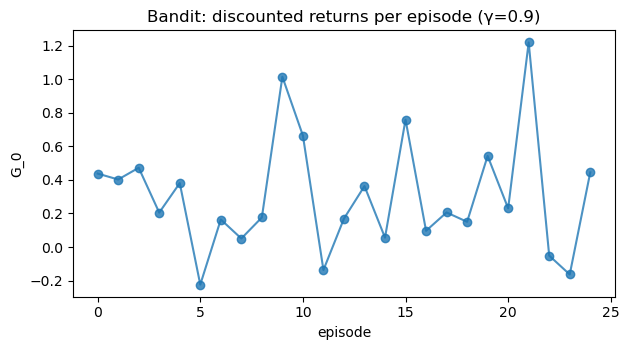

In [13]:
def random_policy(k):
    """Uniform random policy over k actions."""
    return rng.integers(low=0, high=k)

def run_bandit_episodes(env, policy_fn, n_episodes=25, horizon=10, gamma=0.9):
    """
    Simulate n_episodes of length 'horizon' with discount γ.
    Returns:
      - returns: list of total discounted returns per episode
      - rewards_per_ep: list of list of per-step rewards
    """
    all_returns = []
    all_rewards = []
    
    for ep in range(n_episodes):
        obs, info = env.reset()
        rewards = []
        for t in range(horizon):
            a = policy_fn(env.k)
            obs, r, term, trunc, info = env.step(a)
            rewards.append(r)
        # compute discounted return G_0 for this episode
        G = 0.0
        for t, r in enumerate(rewards):
            G += (gamma**t) * r
        all_returns.append(G)
        all_rewards.append(rewards)
    return np.array(all_returns), all_rewards

gamma = 0.9
returns, rewards_per_ep = run_bandit_episodes(
    bandit, random_policy, n_episodes=25, horizon=20, gamma=gamma
)

print("Mean discounted return (random policy):", np.round(returns.mean(), 3))

plot_series(returns, title=f"Bandit: discounted returns per episode (γ={gamma})",
            xlabel="episode", ylabel="G_0")

## 4. Policies as Probability Distributions

A policy $ \pi $ describes how the agent selects actions:

- Deterministic: $ \pi(s) = a $ (a single action per state), or  
- Stochastic: $ \pi(a \mid s) = \Pr[A_t = a \mid S_t = s] $.

In the bandit case (no state), the policy reduces to a distribution over actions $ \pi(a) $.

We want to learn a policy that prefers arms with higher reward.

A simple approach for bandits:

1. Maintain sample-average estimates $ \hat{Q}_t(a) $ of each arm’s value.
2. Select actions via $\varepsilon$-greedy:
   - with probability $ \varepsilon $: explore (random arm),  
   - with probability $ 1 - \varepsilon $: exploit $ \arg\max_a \hat{Q}_t(a) $.

This is a tiny instance of the exploration–exploitation trade-off that appears everywhere in RL.

True means: [ 0.2  0.  -0.1]
ε=0.1 estimates Q: [ 0.199 -0.015 -0.091]
ε=0.0 estimates Q: [0.194 0.    0.   ]


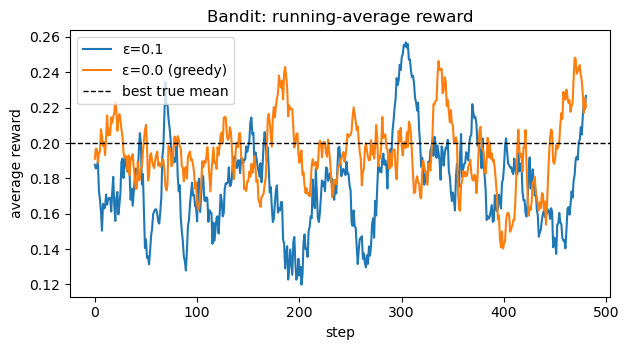

In [14]:
def run_eps_greedy_bandit(env, eps=0.1, steps=500):
    k = env.k
    Q = np.zeros(k) # value estimates
    N = np.zeros(k) # counts
    rewards = []
    
    obs, info = env.reset()
    for t in range(steps):
        # ε-greedy action selection
        if rng.random() < eps:
            a = rng.integers(low=0, high=k)
        else:
            a = int(np.argmax(Q))
        
        obs, r, term, trunc, info = env.step(a)
        rewards.append(r)
        
        # Incremental sample-average update for Q(a)
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
    
    return np.array(rewards), Q, N

steps = 500
rewards_eps01, Q_eps01, N_eps01 = run_eps_greedy_bandit(bandit, eps=0.1, steps=steps)
rewards_eps0,  Q_eps0,  N_eps0  = run_eps_greedy_bandit(bandit, eps=0.0, steps=steps) # purely greedy

print("True means:", bandit.means)
print("ε=0.1 estimates Q:", np.round(Q_eps01, 3))
print("ε=0.0 estimates Q:", np.round(Q_eps0, 3))

# Compare average reward over time
def running_mean(x, window=20):
    x = np.asarray(x)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

plt.figure(figsize=(6.4, 3.6))
plt.plot(running_mean(rewards_eps01), label="ε=0.1")
plt.plot(running_mean(rewards_eps0),  label="ε=0.0 (greedy)")
plt.axhline(np.max(bandit.means), color="k", linestyle="--", linewidth=1, label="best true mean")
plt.title("Bandit: running-average reward")
plt.xlabel("step")
plt.ylabel("average reward")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Markov Property & MDP Preview

So far, our environment had no state. In full RL problems, we typically assume the Markov property:

$$
\Pr[S_{t+1} = s', R_{t+1} = r \mid S_0, A_0, \dots, S_t, A_t]
= \Pr[S_{t+1} = s', R_{t+1} = r \mid S_t, A_t].
$$

That is, the future depends only on the present state and action, not the entire history.

This leads directly to Markov Decision Processes (MDPs):

- State space $ \mathcal{S} $
- Action space $ \mathcal{A} $
- Transition dynamics $ p(s', r \mid s, a) $
- Discount factor $ \gamma $
- Reward function $ r(s,a) $ or $ r(s,a,s') $

In the next notebooks, we will:

- Formalize MDPs,  
- Define value functions $ v_\pi(s), q_\pi(s,a) $,  
- Derive Bellman equations, and  
- Use Dynamic Programming, Monte Carlo, and TD to estimate and improve policies.

The simple bandit you just saw is the “state-free” special case of an MDP.

## Key Takeaways

- The agent–environment loop generates trajectories
  $$
  S_0, A_0, R_1, S_1, \dots
  $$
  which drive learning in RL.
- Returns aggregate future rewards; discounting with $ \gamma $ balances short- vs long-term objectives.
- A policy $ \pi(a \mid s) $ maps states to action distributions; even in bandits, exploration (ε-greedy) is crucial.
- Bandits are the simplest RL setting and a special case of MDPs with no state.
- This notebook’s bandit examples are a gentle prelude to full Markov Decision Processes and value functions.

**Next:** `11_markov_decision_processes.ipynb` → Formal definition of MDPs, Markov property, transition dynamics, and trajectory distributions.